# Association signaux/spectres (source : examen du 04/01/2021)

In [1]:
from numpy import pi
import numpy as np
import numpy.fft as fft
import matplotlib.pyplot as plt

In [37]:
def do(t, signals):
    "Affichage et enregistrement des signaux et spectres"
    
    N = len(t)
    k = np.arange(N) - np.floor(N/2)
    
    # Signaux temporels
    figt, at = plt.subplots(3, 2, figsize=(8,4))
    at = at.flatten()
    for i, x in enumerate(signals):
        at[i].plot(t, x, 'C0')
        at[i].grid()
        at[i].set_xticks(np.arange(0, N+1, 50))
        at[i].set_yticks(np.arange(-1, 2))
        at[i].set_ylim([-1.2, 1.2])
        at[i].text(5, .3,
                   chr(ord("A")+i),
                   fontsize=15, backgroundcolor="#fffa")
        
    plt.tight_layout()
    figt.savefig("signaux.svg")
        
    # Signaux fréquentiels
    order = (4, 1, 2, 0, 5, 3)
    figf, af = plt.subplots(3, 2, figsize=(8,4))
    af = af.flatten()
    for i in range(6):
        x = signals[order[i]]
        X = fft.fftshift(fft.fft(x))
        af[i].plot(k, np.abs(X), 'C2')
        af[i].grid()
        af[i].set_xticks(np.arange(-N/2, N/2+1, N/4))
        af[i].text(-N*.47, .6*np.max(np.abs(X)),
                   str(i+1),
                   fontsize=15, backgroundcolor="#fffa")
        
    plt.tight_layout()
    figf.savefig("spectres.svg")
    

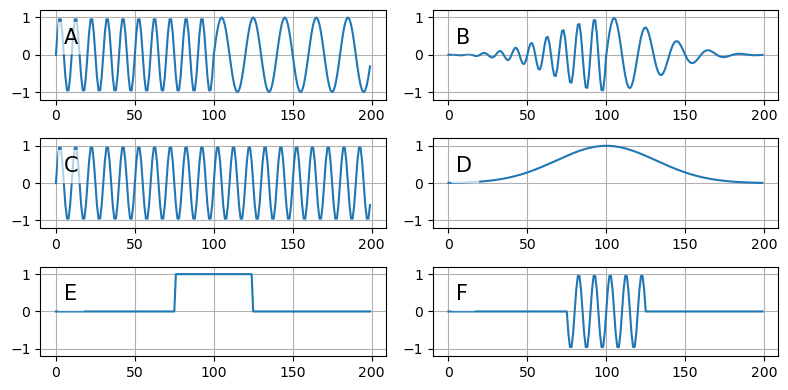

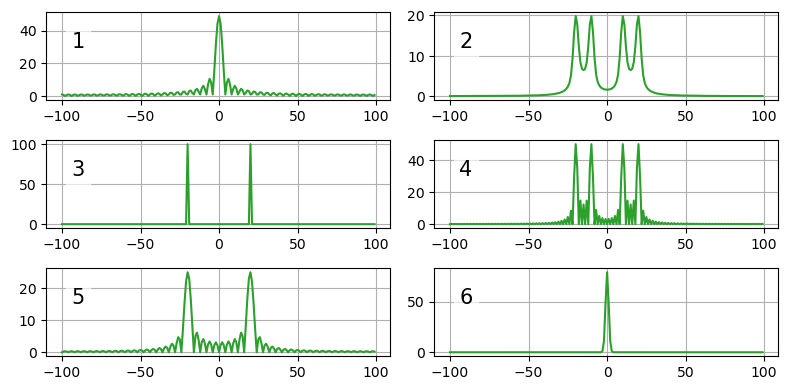

In [38]:
N = 200
t = np.arange(N)
signals = []

# Signal A
signals.append(
    np.where(t<100, np.sin(2*pi*0.1*t), np.sin(2*pi*0.05*t) )
)
    
# Signal B
signals.append(
    np.where(t<100, np.sin(2*pi*0.1*t), np.sin(2*pi*0.05*t) )
    * np.exp(-(t-100)**2/2000)
)

# Signal C
signals.append(
    np.sin(2*pi*0.1*t)
)

# Signal D
signals.append(
    np.exp(-(t-100)**2/2000)
)

# Signal E
signals.append(
    np.where(np.abs(t-100)<25, 1, 0)
)

# Signal F
signals.append(
    np.sin(2*pi*0.1*t)
    * np.where(np.abs(t-100)<25, 1, 0)
)
    
do(t, signals)